In [2]:
# Libraries
import matplotlib.pyplot as plt
import numpy as np

## Hotspot graph

In [3]:
# Data
matrix_sizes = ['n = 2500', 'n = 5000']
critical_section_times = [26.55, 212.23]
overhead_times = [0.16, 0.24]

### Pie Chart

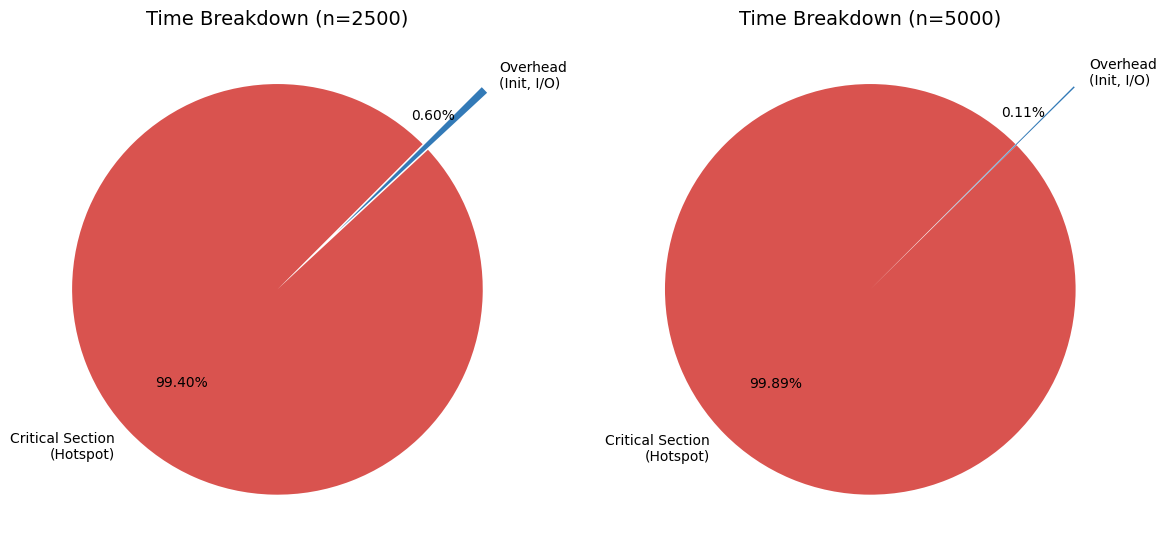

In [13]:
# 2. IMPOSTAZIONI GENERALI PER LA TORTA (PULITA)
labels = ['Critical Section\n(Hotspot)', 'Overhead\n(Init, I/O)']
colors = ['#d9534f', '#337ab7'] # Rosso per l'hotspot, azzurro per l'overhead

# "Esplodiamo" (stacchiamo) la seconda fetta per renderla visibile
explode = (0, 0.4)

# Rimuoviamo il colore del bordo
wedge_properties = {'edgecolor': 'none'}

# 3. CREAZIONE DELLA FIGURA CON DUE GRAFICI AFFIANCATI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# --- Funzione di supporto per spostare l'etichetta verso l'alto ---
def sposta_etichetta_su(autotexts, offset=0.15):
    """Sposta la seconda etichetta percentuale leggermente più in alto."""
    if len(autotexts) > 1:
        x, y = autotexts[1].get_position()
        autotexts[1].set_position((x, y + offset))

# --- Primo grafico: n = 2500 ---
times_2500 = [critical_section_times[0], overhead_times[0]]
_, _, autotexts1 = ax1.pie(times_2500, explode=explode, labels=labels, autopct='%1.2f%%',
                           startangle=45, colors=colors,
                           wedgeprops=wedge_properties,
                           textprops={'fontsize': 10},
                           pctdistance=0.65)
sposta_etichetta_su(autotexts1, offset=0.12)
ax1.set_title('Time Breakdown (n=2500)', fontsize=14)


# --- Secondo grafico: n = 5000 ---
times_5000 = [critical_section_times[1], overhead_times[1]]
_, _, autotexts2 = ax2.pie(times_5000, explode=explode, labels=labels, autopct='%1.2f%%',
                           startangle=45, colors=colors,
                           wedgeprops=wedge_properties,
                           textprops={'fontsize': 10},
                           pctdistance=0.65)
sposta_etichetta_su(autotexts2, offset=0.12)
ax2.set_title('Time Breakdown (n=5000)', fontsize=14)

# 4. SALVATAGGIO IN PDF VETTORIALE
fig.tight_layout()
plt.savefig('hotspot_piecharts_puliti.pdf', format='pdf', bbox_inches='tight')
plt.show()

## Ablation Study: parameter B

In [5]:
# Data
tile_sizes = [8, 16, 32, 64, 128, 256]
execution_times = [42.65, 27.80, 27.21, 22.53, 32.77, 31.23]

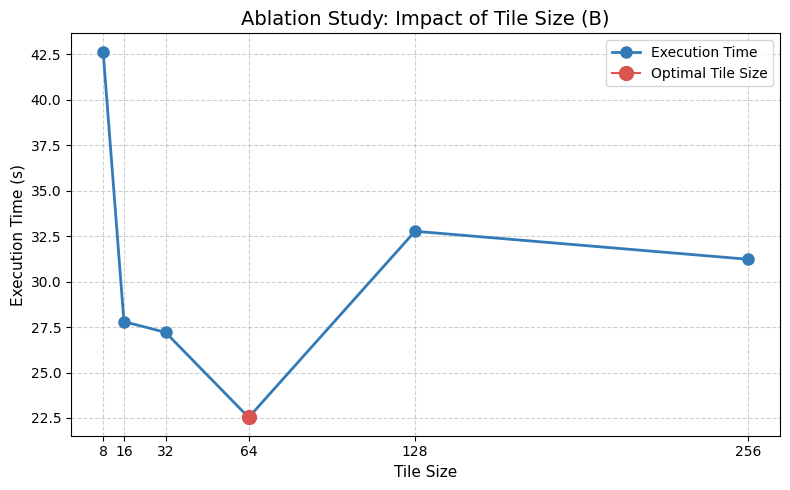

In [6]:
# Trova l'indice del tempo minimo per evidenziarlo
min_time = min(execution_times)
min_index = execution_times.index(min_time)
best_b = tile_sizes[min_index]

# 2. CREAZIONE DEL GRAFICO A LINEE
plt.figure(figsize=(8, 5))

# Disegna la linea principale
plt.plot(tile_sizes, execution_times, marker='o', linestyle='-',
         color='#337ab7', linewidth=2, markersize=8, label='Execution Time')

# Evidenzia il punto ottimale con un marcatore rosso
plt.plot(best_b, min_time, marker='o', color='#d9534f', markersize=10,
         label=f'Optimal Tile Size')

# 3. CONFIGURAZIONE ASSI E STILE
plt.title('Ablation Study: Impact of Tile Size (B)', fontsize=14)
plt.xlabel('Tile Size', fontsize=11)
plt.ylabel('Execution Time (s)', fontsize=11)

# Forza l'asse X a mostrare esattamente i nostri valori di B (potenze di 2)
plt.xticks(tile_sizes, fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=10)

# 4. SALVATAGGIO IN PDF VETTORIALE
plt.tight_layout()
plt.savefig('tile_size_ablation.pdf', format='pdf', bbox_inches='tight')

## Compiler Analysis

In [7]:
# Data
flags = ['Baseline', '-O1', '-O2', '-O3', '-O3+Arch', '-O3+Arch+LTO', '-Ofast']
gcc_times = [978.69, 164.18, 185.97, 60.09, 30.20, 30.21, 30.30]
icc_times = [75.85, 167.77, 68.39, 68.55, 44.03, 44.02, 44.50]
icx_times = [97.86, 253.70, 82.29, 170.72, 22.55, 22.99, 22.98]

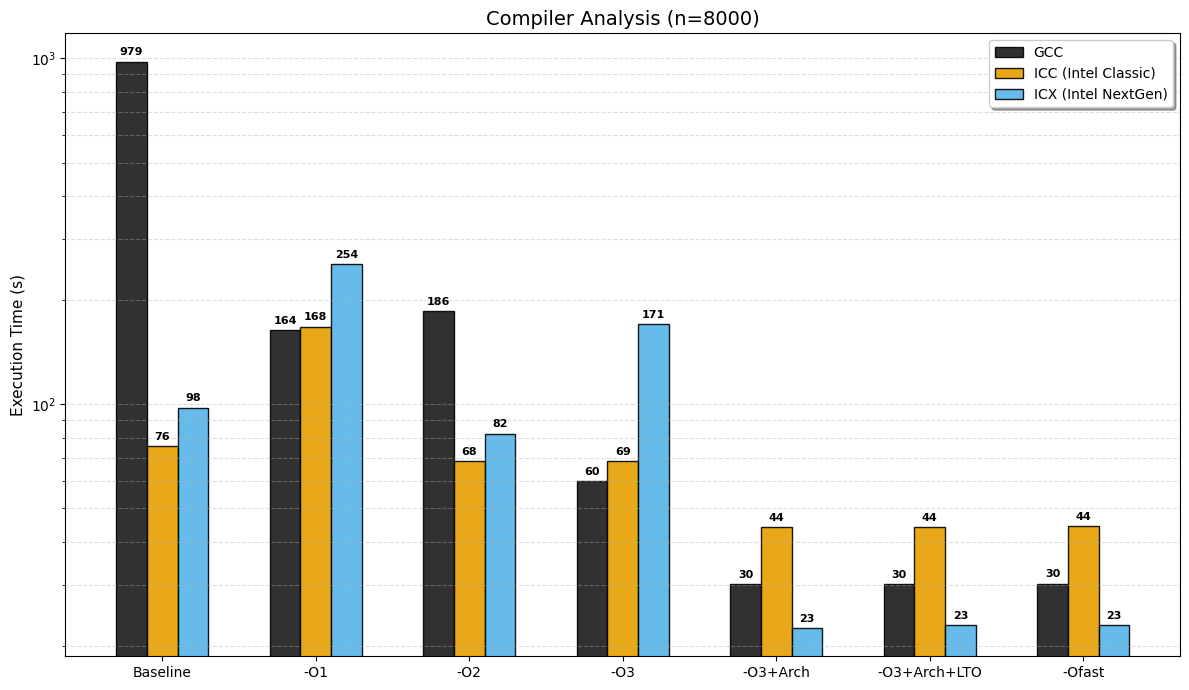

In [8]:
x = np.arange(len(flags))  # Posizioni sull'asse X
width = 0.2               # Larghezza delle singole barre

# 2. CREAZIONE DEL GRAFICO
fig, ax = plt.subplots(figsize=(12, 7))

# Disegno delle barre per ogni compilatore
rects1 = ax.bar(x - width, gcc_times, width, label='GCC', color='#1a1a1a', edgecolor='black', alpha=0.9)
rects2 = ax.bar(x, icc_times, width, label='ICC (Intel Classic)', color='#e69f00', edgecolor='black', alpha=0.9)
rects3 = ax.bar(x + width, icx_times, width, label='ICX (Intel NextGen)', color='#56b4e9', edgecolor='black', alpha=0.9)

# 3. CONFIGURAZIONE SCALA E ASSI
ax.set_yscale('log') # Fondamentale per vedere la differenza tra 900s e 20s
ax.set_ylabel('Execution Time (s)', fontsize=11)
ax.set_title('Compiler Analysis (n=8000)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(flags, fontsize=10, rotation=0)
ax.legend(fontsize=10, frameon=True, shadow=True)

# Griglia orizzontale per facilitare la lettura dei valori logaritmici
ax.grid(axis='y', which='both', linestyle='--', alpha=0.4)

# 4. AGGIUNTA DEI VALORI SOPRA LE BARRE (Opzionale, solo per i più significativi o tutti)
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# 5. SALVATAGGIO
plt.tight_layout()
plt.savefig('compiler_comparison_multibar.pdf', format='pdf', bbox_inches='tight')

## Optimization vs Library

In [9]:
# Data
n_sizes = [1000, 2000, 3000, 5000, 8000, 10000, 15000]
custom_times = [0.04, 0.36, 1.20, 6.02, 22.51, 46.91, 171.66]
cblas_times = [0.03, 0.26, 0.88, 4.06, 16.60, 32.73, 109.43]

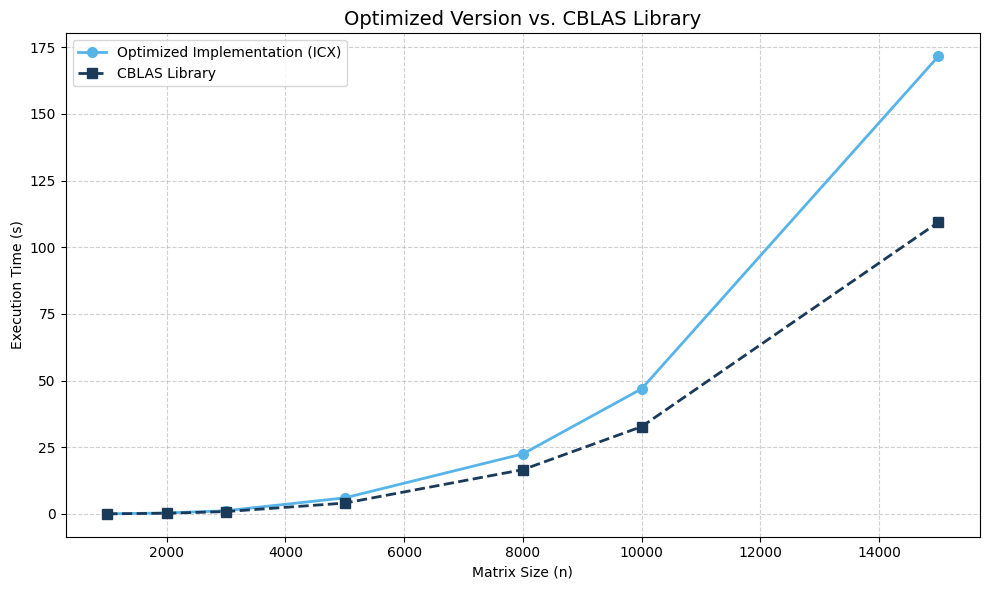

In [14]:
# 2. CREAZIONE DEL GRAFICO
plt.figure(figsize=(10, 6))

# Linea per il codice Custom
plt.plot(n_sizes, custom_times, marker='o', linestyle='-', color='#56b4e9',
         linewidth=2, markersize=7, label='Optimized Implementation (ICX)')

# Linea per CBLAS
plt.plot(n_sizes, cblas_times, marker='s', linestyle='--', color='#1a3a5a',
         linewidth=2, markersize=7, label='CBLAS Library')

# 3. CONFIGURAZIONE ASSI E STILE
plt.title('Optimized Version vs. CBLAS Library', fontsize=14)
plt.xlabel('Matrix Size (n)', fontsize=10)
plt.ylabel('Execution Time (s)', fontsize=10)

# Griglia per facilitare la lettura
plt.grid(True, linestyle='--', alpha=0.6)

# Legenda
plt.legend(fontsize=10, loc='upper left')

# 4. SALVATAGGIO IN PDF VETTORIALE
plt.tight_layout()
plt.savefig('custom_vs_cblas_scaling.pdf', format='pdf', bbox_inches='tight')